# Exploratory Data Analysis (EDA)

Notebook này thực hiện quá trình Phân tích dữ liệu Khám phá (Exploratory Data Analysis - EDA) trên tập dữ liệu Netflix. Mục tiêu là hiểu rõ hơn về tập dữ liệu, làm sạch dữ liệu, tìm ra các mô hình (patterns), và chuẩn bị dữ liệu cho các bước tiếp theo.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

# Configure visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
warnings.filterwarnings('ignore')

## Data Overview

Bước đầu tiên trong hành trình phân tích là đọc tập dữ liệu và có được góc nhìn tổng quát thông qua shape (số chiều), các cột, loại dữ liệu tương ứng, cùng việc đưa ra vài mẩu mẫu dữ liệu đại diện.

In [2]:
# Load data
df = pd.read_csv('../data/raw/netflix_movies_detailed_up_to_2025.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

# Display sample rows
df.head()

Dataset Shape: (16000, 18)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-nul

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


## Data Cleaning & Preprocessing

Kiểm tra số lượng dữ liệu bị thiếu (missing values) và các bản ghi trùng lặp. Quyết định hướng xử lý chúng dựa trên ý nghĩa ngữ cảnh. Ví dụ như drop (xóa) những dòng có chứa null đối với các feature quan trọng và/hoặc fill (điền dữ liệu tương đương) với những feature có thể bù đắp thông tin bằng placeholder/mode/mean.

In [3]:
# Check for missing values
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_data, 'Percentage (%)': missing_percentage})

print("Missing Data Summary:\n")
print(missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False))

# Check for duplicates
print(f"\nNumber of Duplicate Rows: {df.duplicated().sum()}")

Missing Data Summary:

             Missing Values  Percentage (%)
duration              16000       100.00000
country                 466         2.91250
cast                    204         1.27500
director                132         0.82500
description             132         0.82500
genres                  107         0.66875

Number of Duplicate Rows: 0


## Univariate Analysis

Tiến hành phân tích Phân phối Tần suất Đơn biến (Univariate Analysis) để xem xét sự phân bố của các thuộc tính dạng phân loại (categorical) như `type`, các numerical features (như `release_year`, `rating`, `duration`, v.v.). Điều này cho phép ta hiểu sâu hơn về độ tuổi của các tựa phim, mức độ đánh giá cũng như thời lượng phổ biến trên Netflix.

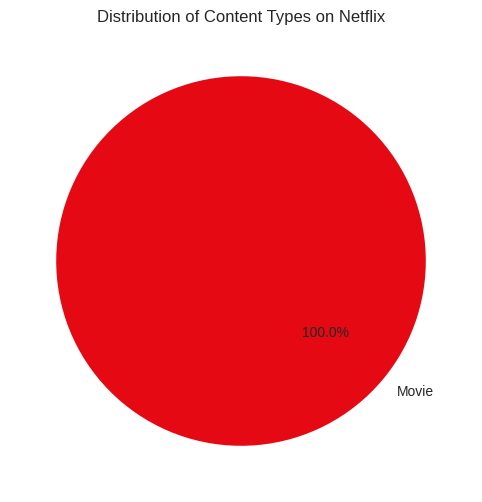

In [5]:
# Content Type Distribution
type_counts = df['type'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=['#E50914', '#221F1F'])
plt.title('Distribution of Content Types on Netflix')
plt.show()

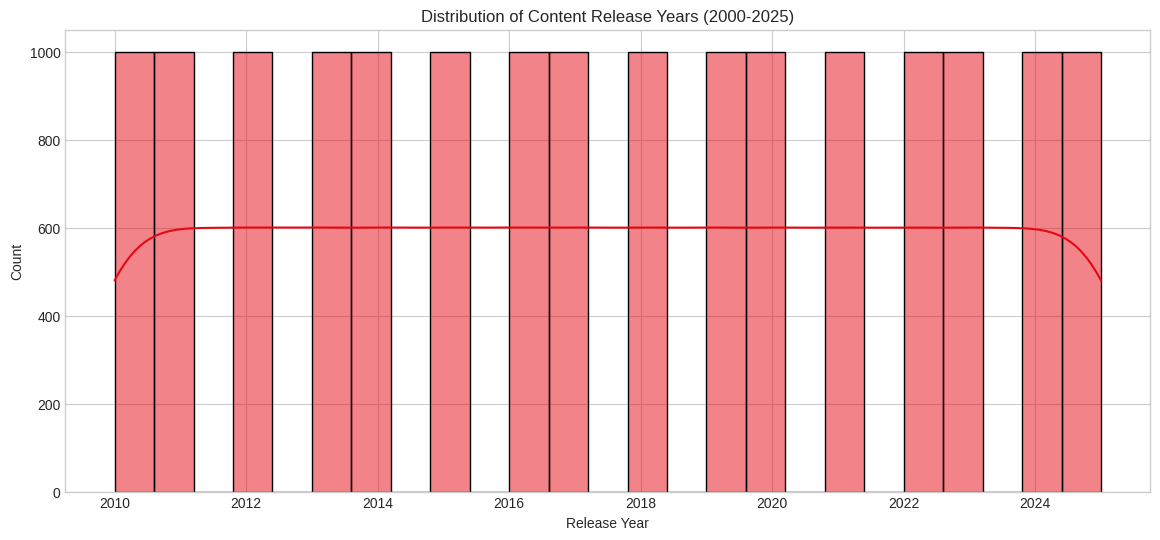

In [6]:
# Release Year distribution (focusing on year 2000 onwards)
recent_years = df[df['release_year'] >= 2000]

plt.figure(figsize=(14, 6))
sns.histplot(data=recent_years, x='release_year', bins=25, kde=True, color='#E50914')
plt.title('Distribution of Content Release Years (2000-2025)')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

## Bivariate / Multivariate Analysis

Tiếp tục phân tích tương quan giữa các biến để tìm ra xu hướng (trend). So sánh số lượng phim/Movie và chương trình truyền hình/TV Show được thêm vào hệ thống qua từng năm. Bằng việc thực hiện tính toán giá trị tương quan (Correlation heatmap) trên các dữ liệu dạng numeric, chúng ta có thể đánh giá độ liên hệ giữa các điểm số tính toán liên quan đến ngân sách (`budget`), doanh thu (`revenue`), và điểm đánh giá (`vote_average`, `popularity`).

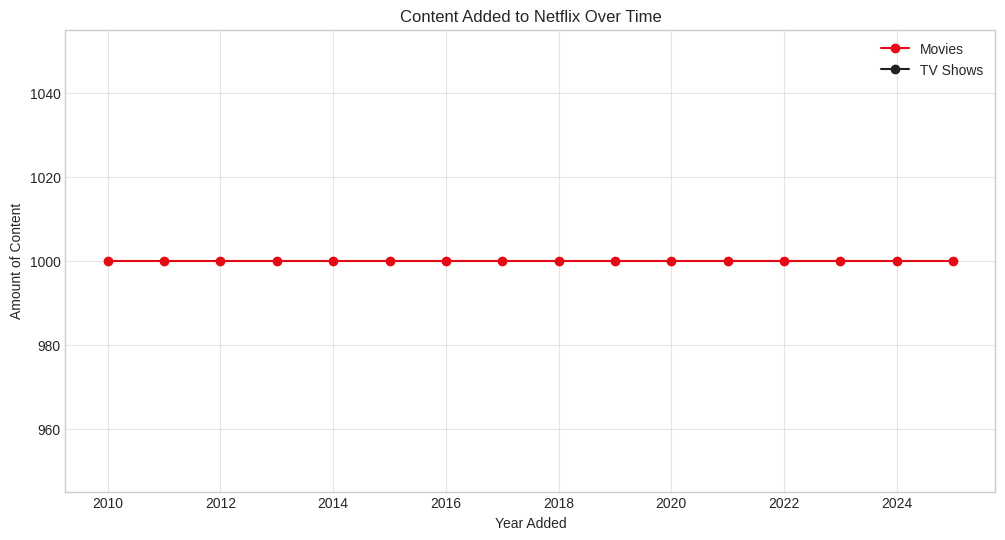

In [7]:
# Trend of Content Added Over the Years
movies_added = df[df['type'] == 'Movie'].groupby('year_added').size()
tv_shows_added = df[df['type'] == 'TV Show'].groupby('year_added').size()

plt.figure(figsize=(12, 6))
plt.plot(movies_added.index, movies_added.values, label='Movies', color='#E50914', marker='o')
plt.plot(tv_shows_added.index, tv_shows_added.values, label='TV Shows', color='#221F1F', marker='o')
plt.title('Content Added to Netflix Over Time')
plt.xlabel('Year Added')
plt.ylabel('Amount of Content')
plt.legend()
plt.grid(axis='both', alpha=0.5)
plt.show()

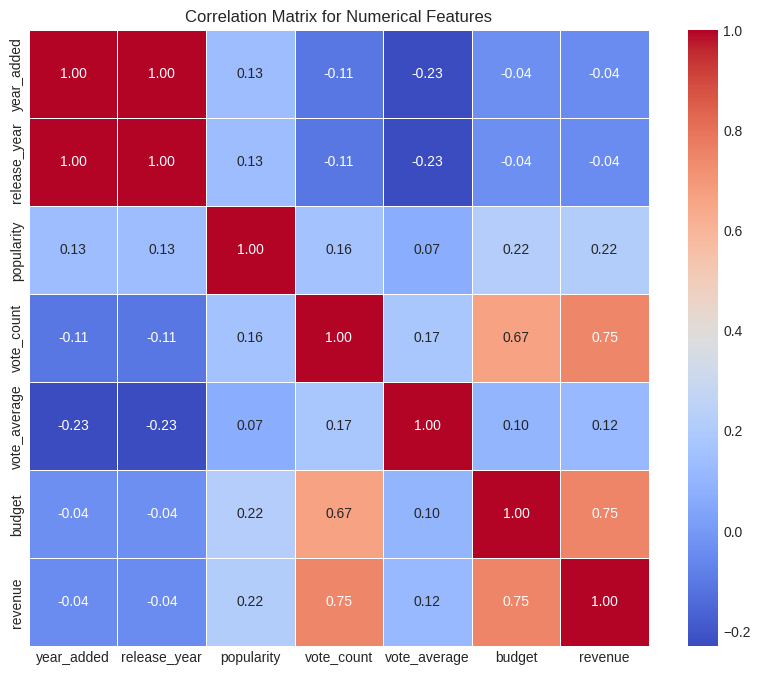

In [8]:
# Correlation Heatmap for Numerical Features
numerical_cols = ['year_added', 'release_year', 'popularity', 'vote_count', 'vote_average', 'budget', 'revenue']
corr_matrix = df[numerical_cols].dropna().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix for Numerical Features')
plt.show()

In [9]:
# Print all language of feature language
print("Unique Languages in the Dataset:")
print(df['language'].unique())

Unique Languages in the Dataset:
['en' 'es' 'sr' 'pt' 'ko' 'fr' 'hi' 'ja' 'th' 'no' 'de' 'zh' 'it' 'fi'
 'cn' 'sv' 'is' 'ta' 'nl' 'da' 'ru' 'tr' 'el' 'te' 'bn' 'ar' 'ca' 'fa'
 'ro' 'he' 'cs' 'hu' 'pl' 'ml' 'ms' 'id' 'ku' 'xx' 'tl' 'gl' 'lt' 'si'
 'et' 'hr' 'ps' 'mi' 'uk' 'af' 'km' 'mr' 'sk' 'kn' 'eu' 'lv' 'la' 'dz'
 'kk' 'mk' 'ka' 'vi' 'mn' 'pa' 'ga' 'yo' 'zu' 'ky' 'ur' 'kl' 'ht' 'am'
 'ne' 'hy' 'sl' 'bg']


## Feature Insights

Thông qua phân tích dữ liệu trên, ta có thể đưa ra một số nhận định sau:
- **Ngân sách (Budget) và Doanh thu (Revenue):** Hai yếu tố này có tương quan thuận chiều mạnh mẽ với nhau, đi kèm là chỉ số Vote count (Số lượng lượt bình chọn) cũng gia tăng đáng kể ở nhóm phim có mức độ đầu tư lớn.
- **Phân bổ Content:** Netflix tiếp tục thống trị bởi thể loại Movies, tuy nhiên có sự phát triển nhất định với hình thức TV shows trong các năm về sau (chúng ta có thể phân tích thêm xu hướng chia nhỏ thể loại thay vì loại hình phim dài). 
- **Release Timeline:** Phần lớn dữ liệu được bổ sung mạnh mẽ vào hệ thống sau những năm 2010.

Với những kiến thức và thông tin khai thác được, bộ dữ liệu đã sẵn sàng để đem tới các phase tiếp theo như tiền xử lý cho mô hình dự đoán (Machine Learning models) hoặc là làm trực quan hoá dữ liệu động trên Streamlit.